In [55]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import seaborn as sns
import wordcloud

In [26]:
# read the CSV
df = pd.read_csv("Lecture_6_Data/AllBooks_baseline_DTM_Labelled.csv", index_col = 0)
df

,foolishness,hath,wholesome,takest,feelings,anger,vaivaswata,matrix,kindled,convict,...,erred,thinkest,modern,reigned,sparingly,visual,thoughts,illumines,attire,explains
Buddhism_Ch1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Buddhism_Ch2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Buddhism_Ch3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Buddhism_Ch4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Buddhism_Ch5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
BookOfWisdom_Ch15,0,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BookOfWisdom_Ch16,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BookOfWisdom_Ch17,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
BookOfWisdom_Ch18,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [27]:
list_of_text = df.index
list_of_text

Index(['Buddhism_Ch1', 'Buddhism_Ch2', 'Buddhism_Ch3', 'Buddhism_Ch4',
       'Buddhism_Ch5', 'Buddhism_Ch6', 'Buddhism_Ch7', 'Buddhism_Ch8',
       'Buddhism_Ch9', 'Buddhism_Ch10',
       ...
       'BookOfWisdom_Ch10', 'BookOfWisdom_Ch11', 'BookOfWisdom_Ch12',
       'BookOfWisdom_Ch13', 'BookOfWisdom_Ch14', 'BookOfWisdom_Ch15',
       'BookOfWisdom_Ch16', 'BookOfWisdom_Ch17', 'BookOfWisdom_Ch18',
       'BookOfWisdom_Ch19'],
      dtype='object', length=590)

In [28]:
# declare a dictionary
books = {}

for text in list_of_text:
    split_book = text.split("_")
    book = split_book[0]
    
    # check if book is in the dictionary
    if book in books:
        # if it is, increase count by 1
        books[book] += 1
    else:
        # create a new key:value pair
        books[book] = 1

In [29]:
books

{'Buddhism': 46,
 'TaoTeChing': 81,
 'Upanishad': 162,
 'YogaSutra': 189,
 'BookOfProverb': 31,
 'BookOfEcclesiastes': 12,
 'BookOfEccleasiasticus': 50,
 'BookOfWisdom': 19}

In [64]:
# Process of training a model
# 1. declare model
# 2. fit data into model
# 3. perform prediction

# we have to declare the number of clusters to cluster our dataset
kmeans = KMeans(n_clusters = 6)
k_fit = kmeans.fit(df)
k_fit

KMeans(n_clusters=6)

In [65]:
new_df = pd.DataFrame(df.index)
new_df['pred_labels'] = k_fit.predict(df)
new_df

,0,pred_labels
0,Buddhism_Ch1,2
1,Buddhism_Ch2,2
2,Buddhism_Ch3,2
3,Buddhism_Ch4,2
4,Buddhism_Ch5,2
...,...,...
585,BookOfWisdom_Ch15,0
586,BookOfWisdom_Ch16,1
587,BookOfWisdom_Ch17,2
588,BookOfWisdom_Ch18,0


In [66]:
# rename the columns in new df
new_df.columns = ['text', 'pred_labels']
new_df

,text,pred_labels
0,Buddhism_Ch1,2
1,Buddhism_Ch2,2
2,Buddhism_Ch3,2
3,Buddhism_Ch4,2
4,Buddhism_Ch5,2
...,...,...
585,BookOfWisdom_Ch15,0
586,BookOfWisdom_Ch16,1
587,BookOfWisdom_Ch17,2
588,BookOfWisdom_Ch18,0


In [67]:
# declare multiple new columns
new_df[['split_text', 'chapter']] = new_df['text'].str.split("_", expand = True)
new_df

,text,pred_labels,split_text,chapter
0,Buddhism_Ch1,2,Buddhism,Ch1
1,Buddhism_Ch2,2,Buddhism,Ch2
2,Buddhism_Ch3,2,Buddhism,Ch3
3,Buddhism_Ch4,2,Buddhism,Ch4
4,Buddhism_Ch5,2,Buddhism,Ch5
...,...,...,...,...
585,BookOfWisdom_Ch15,0,BookOfWisdom,Ch15
586,BookOfWisdom_Ch16,1,BookOfWisdom,Ch16
587,BookOfWisdom_Ch17,2,BookOfWisdom,Ch17
588,BookOfWisdom_Ch18,0,BookOfWisdom,Ch18


In [68]:
unique_texts = new_df['split_text'].unique()
unique_texts

array(['Buddhism', 'TaoTeChing', 'Upanishad', 'YogaSutra',
       'BookOfProverb', 'BookOfEcclesiastes', 'BookOfEccleasiasticus',
       'BookOfWisdom'], dtype=object)

In [69]:
new_df[new_df['split_text'] == 'TaoTeChing']['pred_labels'].value_counts()

2    81
Name: pred_labels, dtype: int64

In [70]:
# Come back at 710pm

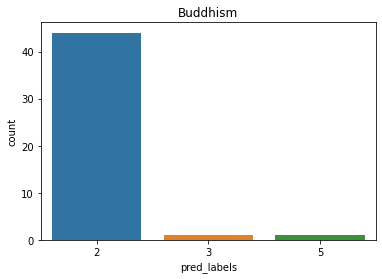

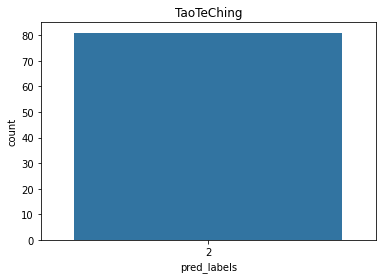

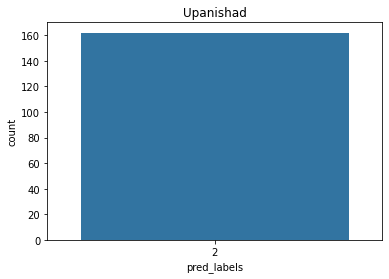

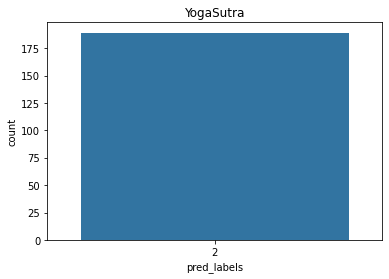

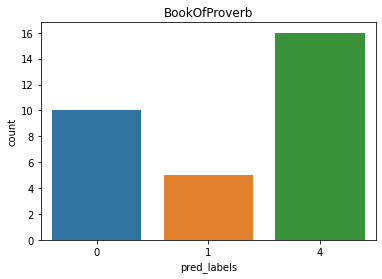

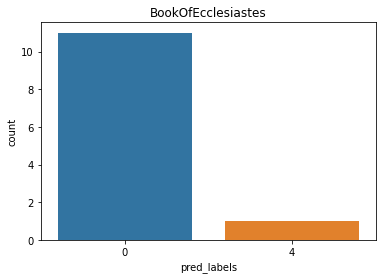

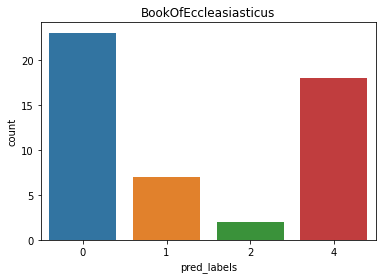

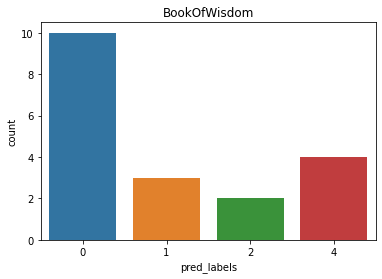

In [71]:
for text in unique_texts:
    # get a temporary df based on what text is in the loop
    temp_df = new_df[new_df['split_text'] == text]
    sns.countplot(temp_df['pred_labels'])
    plt.title(text)
    plt.show()

In [57]:
k_fit.inertia_

119095.73907381934

In [58]:
kmeans_2 = KMeans(n_clusters = 3)
k_fit_2 = kmeans_2.fit(df)
k_fit_2

KMeans(n_clusters=3)

In [59]:
k_fit_2.inertia_

124758.63867990552

In [60]:
inertias = []

for n in range(1, 16):
    temp_kmeans = KMeans(n_clusters = n)
    temp_k_fit = temp_kmeans.fit(df)
    inertias.append(temp_k_fit.inertia_)

C:\Users\Jack\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:881: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


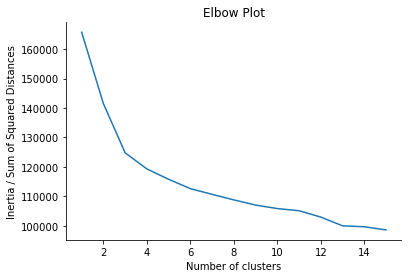

In [63]:
# Plot inertia vs cluster number
plt.xlabel('Number of clusters') # labels x axis
plt.ylabel('Inertia / Sum of Squared Distances')
plt.title('Elbow Plot')
plt.plot(range(1, 16), inertias)
sns.despine() # makes your plot look nicer

In [72]:
# wordcloud analysis

# Read the text file into a list with .readlines
with open("Lecture_6_Data/Complete_data .txt") as f:
    line = f.readlines()

line

['0.1\n',
 '§ 1.The Buddha: "What do you think, Rahula: What is a mirror for?"The Buddha:Rahula: "For reflection, sir."Rahula:The Buddha: "In the same way, Rahula, bodily acts, verbal acts, & mental acts are to be done with repeated reflection.The Buddha:"Whenever you want to perform a bodily act, you should reflect on it: \'This bodily act I want to perform — would it lead to self-affliction, to the affliction of others, or to both? Is it an unskillful bodily act, with painful consequences, painful results?\' If, on reflection, you know that it would lead to self-affliction, to the affliction of others, or to both; it would be an unskillful bodily act with painful consequences, painful results, then any bodily act of that sort is absolutely unfit for you to do. But if on reflection you know that it would not cause affliction... it would be a skillful bodily act with happy consequences, happy results, then any bodily act of that sort is fit for you to do.(Similarly with verbal acts & m

In [74]:
chapter = []
lines = []

for row in range(len(line)):
    if row % 2 == 0:
        chapter.append(line[row].strip())
    else:
        lines.append(line[row])

In [75]:
text_df = pd.DataFrame({'chapter': chapter,
                        'line': lines})
text_df

,chapter,line
0,0.1,"§ 1.The Buddha: ""What do you think, Rahula: Wh..."
1,0.2,§ 2.Once the Blessed One was staying at Kosamb...
2,0.3,"§ 3.""'Stress should be known. The cause by whi..."
3,0.4,"§ 4.""Vision arose, clear knowing arose, discer..."
4,0.5,"§ 5.Sariputta: ""There are these three forms of..."
...,...,...
585,7.15,condemning both the makers and the worshippers...
586,7.16,"worthily punished, and were destroyed by a mul..."
587,7.17,"17:1. For thy judgments, O Lord, are great, a..."
588,7.18,"intercession, in the sedition on occasion of C..."


In [76]:
buddhism = text_df[:46]
buddhism

,chapter,line
0,0.1,"§ 1.The Buddha: ""What do you think, Rahula: Wh..."
1,0.2,§ 2.Once the Blessed One was staying at Kosamb...
2,0.3,"§ 3.""'Stress should be known. The cause by whi..."
3,0.4,"§ 4.""Vision arose, clear knowing arose, discer..."
4,0.5,"§ 5.Sariputta: ""There are these three forms of..."
5,0.6,"§ 6.Sariputta: ""Now what, friends, is the nobl..."
6,0.7,"§ 7.At Savatthi. There the Blessed One said, ""..."
7,0.8,"§ 8.The Buddha: ""These are the five clinging-a..."
8,0.9,"§ 9.""And why do you call it 'form' (rupa)? Bec..."
9,0.10,"§ 10.MahaKotthita: ""Feeling, perception, & con..."


In [77]:
wisdom = text_df[-19:]
wisdom

,chapter,line
571,7.1,"desireth not our death. 1:1. Love justice, yo..."
572,7.2,especially the Son of God. 2:1. For they have...
573,7.3,3:1. But the souls of the just are in the han...
574,7.4,between the death of the just and the wicked. ...
575,7.5,the just. 5:1. Then shall the just stand with...
576,7.6,that seek her. 6:1. Wisdom is better than str...
577,7.7,"7:1. I myself am a mortal man, like all other..."
578,7.8,"8:1. She reacheth, therefore, from end to end..."
579,7.9,"9:1. God of my fathers, and Lord of mercy, wh..."
580,7.10,"people of Israel. 10:1. She preserved him, th..."


In [82]:
buddhism_joined = " ".join(buddhism['line'])
wisdom_joined = " ".join(wisdom['line'])

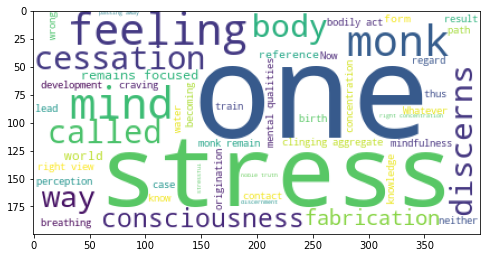

In [86]:
plt.figure(figsize = (8, 4.5 ))
b_wc = wordcloud.WordCloud(max_words = 50, background_color = 'white')
b_cloud = b_wc.generate(buddhism_joined)
plt.imshow(b_cloud)
plt.show()

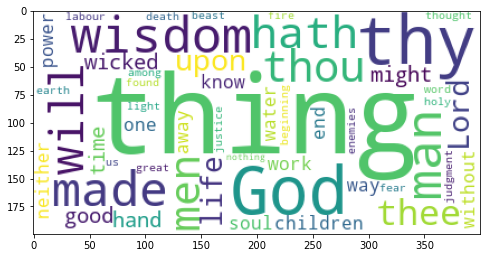

In [87]:
plt.figure(figsize = (8, 4.5 ))
w_wc = wordcloud.WordCloud(max_words = 50, background_color = 'white')
w_cloud = w_wc.generate(wisdom_joined)
plt.imshow(w_cloud)
plt.show()